=== 📂 [2단계] 데이터 수집 및 설명 시작 ===
✅ 데이터셋 로드 완료!
👉 전체 데이터(샘플) 개수: 10299개
👉 전체 변수(특징 + 라벨) 개수: 562개

=== 📊 활동 라벨별 데이터 분포 ===
• Walking (라벨 1): 1722개
• Walking Upstairs (라벨 2): 1544개
• Walking Downstairs (라벨 3): 1406개
• Sitting (라벨 4): 1777개
• Standing (라벨 5): 1906개
• Laying (라벨 6): 1944개


/tmp/ipykernel_14061/4202783792.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y.map(activity_names), palette='viridis')


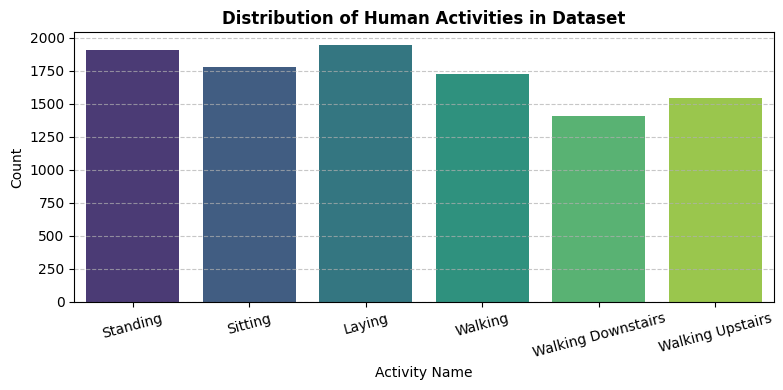

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=== 📂 [2단계] 데이터 수집 및 설명 시작 ===")

# 1. CSV 파일 불러오기
df = pd.read_csv('스마트폰_센서_데이터셋.csv')

# 2. 데이터 크기 및 구조 확인
print(f"✅ 데이터셋 로드 완료!")
print(f"👉 전체 데이터(샘플) 개수: {df.shape[0]}개")
print(f"👉 전체 변수(특징 + 라벨) 개수: {df.shape[1]}개")

# 3. 피처(X)와 라벨(y) 분리하기
X = df.drop(columns=['Activity_Label'])
y = df['Activity_Label']

# 4. 클래스(활동)별 데이터 분포 확인
activity_counts = y.value_counts().sort_index()
print("\n=== 📊 활동 라벨별 데이터 분포 ===")
activity_names = {1: 'Walking', 2: 'Walking Upstairs', 3: 'Walking Downstairs', 4: 'Sitting', 5: 'Standing', 6: 'Laying'}
for k, v in activity_names.items():
    print(f"• {v} (라벨 {k}): {activity_counts[k]}개")

# 5. 데이터 분포 시각화
plt.figure(figsize=(8, 4))
sns.countplot(x=y.map(activity_names), palette='viridis')
plt.title('Distribution of Human Activities in Dataset', fontsize=12, fontweight='bold')
plt.xlabel('Activity Name')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


=== 🛠️ [3단계] 데이터 전처리 및 차원 축소 시작 ===
👉 데이터셋 내 결측치 개수: 0개
✅ StandardScaler 표준화 완료!
✅ PC1 분산 설명력: 50.74%
✅ PC2 분산 설명력: 6.24%
👉 단 2개의 주성분으로 전체 데이터가 가진 정보의 56.98%를 보존했습니다.


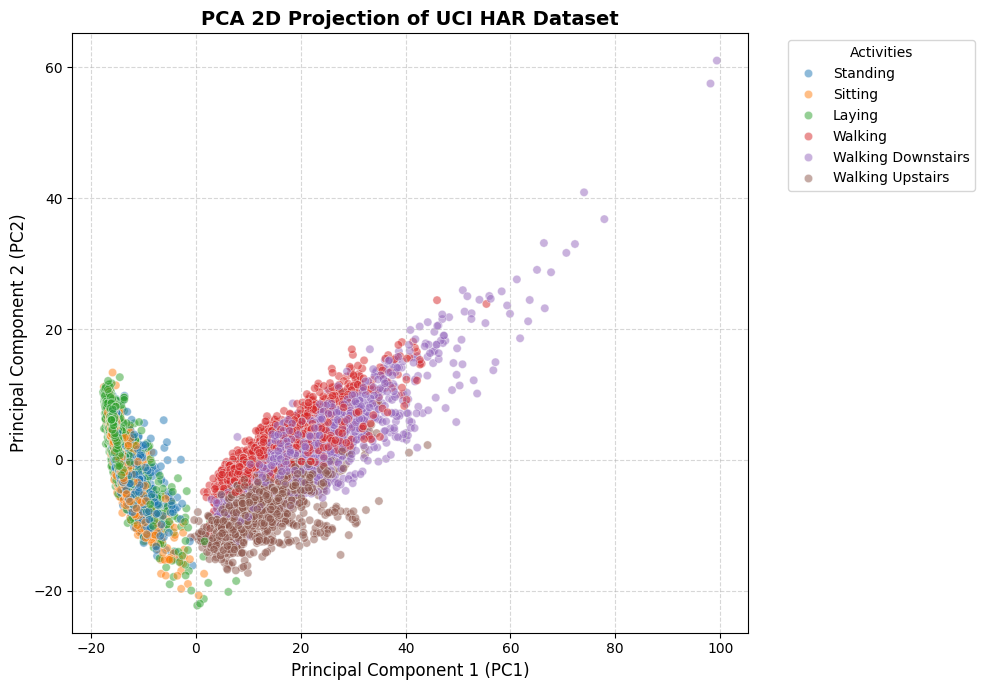

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("\n=== 🛠️ [3단계] 데이터 전처리 및 차원 축소 시작 ===")

# 1. 결측치(Null) 확인 및 제거
null_sum = X.isnull().sum().sum()
print(f"👉 데이터셋 내 결측치 개수: {null_sum}개")
if null_sum > 0:
    X = X.fillna(X.mean()) # 혹시 모를 결측치는 평균값으로 대체
    print("⚠️ 결측치가 발견되어 평균값으로 대체 전처리했습니다.")

# 2. StandardScaler (데이터 표준화)
# 가속도와 자이로스코프의 단위를 평균 0, 분산 1로 통일하여 거리 왜곡을 방지합니다.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✅ StandardScaler 표준화 완료!")

# 3. PCA (주성분 분석) 적용
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 시각화 편의를 위해 데이터프레임 빌드
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Activity_Name'] = y.map(activity_names).values

# 4. 설명 분산 비율(Explained Variance Ratio) 출력
explained_variance = pca.explained_variance_ratio_
print(f"✅ PC1 분산 설명력: {explained_variance[0]:.2%}")
print(f"✅ PC2 분산 설명력: {explained_variance[1]:.2%}")
print(f"👉 단 2개의 주성분으로 전체 데이터가 가진 정보의 {sum(explained_variance):.2%}를 보존했습니다.")

# 5. PCA 2D 산점도 시각화
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Activity_Name',
    palette='tab10',
    data=df_pca,
    alpha=0.5
)
plt.title('PCA 2D Projection of UCI HAR Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.legend(title='Activities', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

=== 🤖 [4단계] K-Means 군집화 및 파라미터 튜닝 시작 ===
✅ 군집 수(K)별 Inertia 계산 완료!


/tmp/ipykernel_14061/382183095.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K_range, inertia, 'bx-', color='teal', markersize=8, linewidth=2)


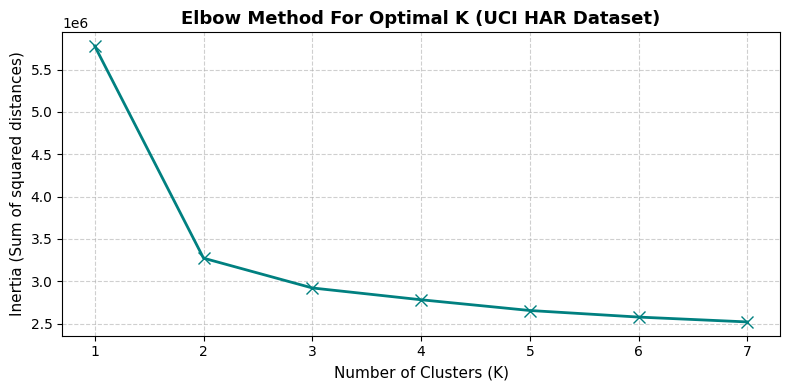

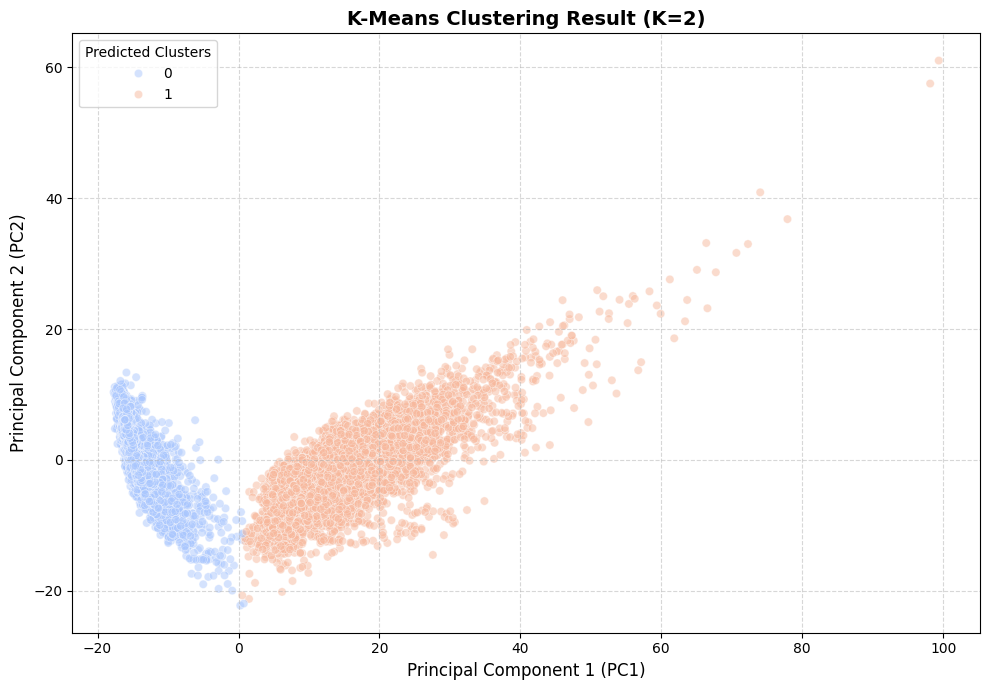


=== 📊 실제 활동 라벨과 군집화 결과 비교 (Cross Tabulation) ===
Cluster Label (0-1)     0     1
Actual Activity                
Laying               1932    12
Sitting              1774     3
Standing             1906     0
Walking                 0  1722
Walking Downstairs      0  1406
Walking Upstairs        8  1536

=== 🔍 [추가 분석] K=6 일 때의 군집화 결과 및 한계점 분석 ===


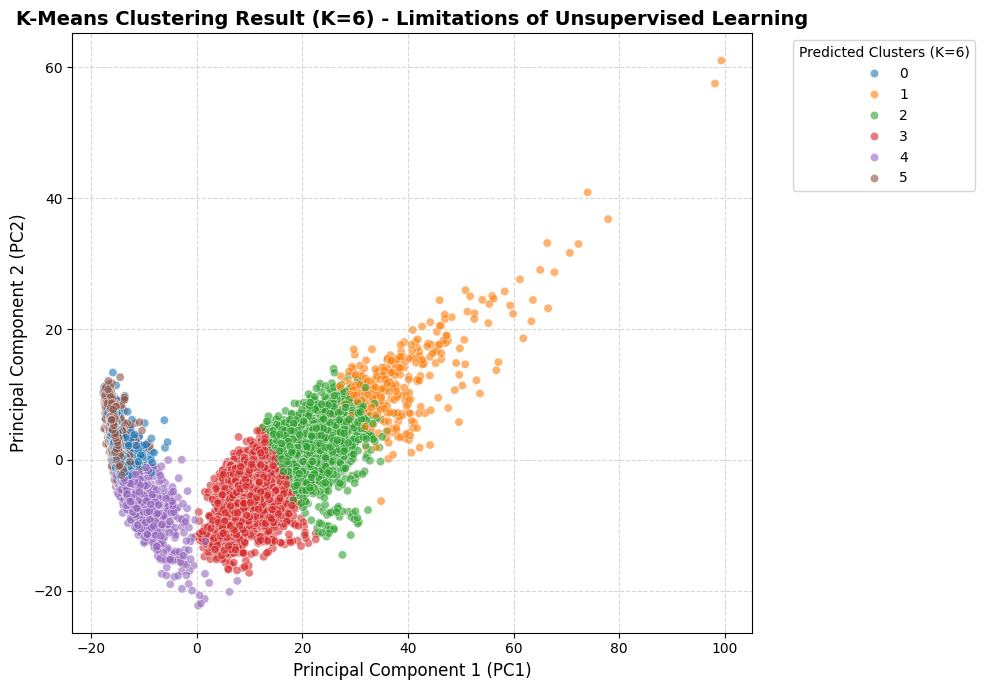


=== 📊 [K=6] 실제 활동 라벨과 군집화 결과 비교 (Cross Tabulation) ===
Cluster Label (0-5)     0    1    2     3    4     5
Actual Activity                                     
Laying                 54    0    0     5  329  1556
Sitting              1238    0    0     1  447    91
Standing             1346    0    0     0  560     0
Walking                 0   84  741   897    0     0
Walking Downstairs      0  214  882   310    0     0
Walking Upstairs        0    9  297  1236    2     0


In [3]:
from sklearn.cluster import KMeans

print("=== 🤖 [4단계] K-Means 군집화 및 파라미터 튜닝 시작 ===")

# --- 1. Elbow Method를 이용한 최적의 K(군집 수) 탐색 ---
inertia = []
K_range = range(1, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)  # 표준화된 전처리 데이터를 사용합니다.
    inertia.append(kmeans.inertia_)

print("✅ 군집 수(K)별 Inertia 계산 완료!")

# 2. 엘보우 그래프 시각화
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-', color='teal', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (K)', fontsize=11)
plt.ylabel('Inertia (Sum of squared distances)', fontsize=11)
plt.title('Elbow Method For Optimal K (UCI HAR Dataset)', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# --- 3. K=2 (동적 활동 vs 정적 활동)로 실제 군집화 수행 ---
kmeans_model = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X_scaled)

# 에러 방지를 위해 새로운 결과 데이터프레임을 명확하게 생성합니다.
df_analysis = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_analysis['Actual_Activity'] = y.values
df_analysis['Activity_Name'] = df_analysis['Actual_Activity'].map(activity_names)
df_analysis['Cluster_Label'] = cluster_labels

# 4. K-Means 군집화 결과 시각화
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster_Label',
    palette='coolwarm',
    data=df_analysis,
    alpha=0.5
)
plt.title('K-Means Clustering Result (K=2)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.legend(title='Predicted Clusters')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 5. 실제 라벨과 군집화 결과 매핑 비교 (교차표 분석)
print("\n=== 📊 실제 활동 라벨과 군집화 결과 비교 (Cross Tabulation) ===")
cross_tab = pd.crosstab(df_analysis['Activity_Name'], df_analysis['Cluster_Label'],
                        rownames=['Actual Activity'], colnames=['Cluster Label (0-1)'])
print(cross_tab)

# 추가 분석: K=6 (실제 활동 개수)일 때의 비지도 군집화 수행 및 한계 도출
print("\n" + "="*50)
print("=== 🔍 [추가 분석] K=6 일 때의 군집화 결과 및 한계점 분석 ===")
print("="*50)

# 1. 실제 활동 개수인 K=6으로 설정하여 군집화 수행
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels_6 = kmeans_6.fit_predict(X_scaled)

# 분석 데이터프레임에 K=6 결과 컬럼 추가
df_analysis['Cluster_Label_K6'] = cluster_labels_6

# 2. K=6 군집화 결과 시각화
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster_Label_K6',
    palette='tab10',
    data=df_analysis,
    alpha=0.6
)
plt.title('K-Means Clustering Result (K=6) - Limitations of Unsupervised Learning', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.legend(title='Predicted Clusters (K=6)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 3. K=6 일 때의 실제 라벨과 군집 결과 매핑 비교 (교차표 분석)
print("\n=== 📊 [K=6] 실제 활동 라벨과 군집화 결과 비교 (Cross Tabulation) ===")
cross_tab_6 = pd.crosstab(df_analysis['Activity_Name'], df_analysis['Cluster_Label_K6'],
                          rownames=['Actual Activity'], colnames=['Cluster Label (0-5)'])
print(cross_tab_6)


=== 🎯 [5단계] K-NN 분류 모델 학습 및 평가 시작 ===
✅ 학습 데이터(Train)와 테스트 데이터(Test) 분리 완료!
👉 학습용 데이터: 7209개, 테스트용 데이터: 3090개

⏳ 최적의 K값을 탐색 중입니다. 잠시만 기다려주세요...


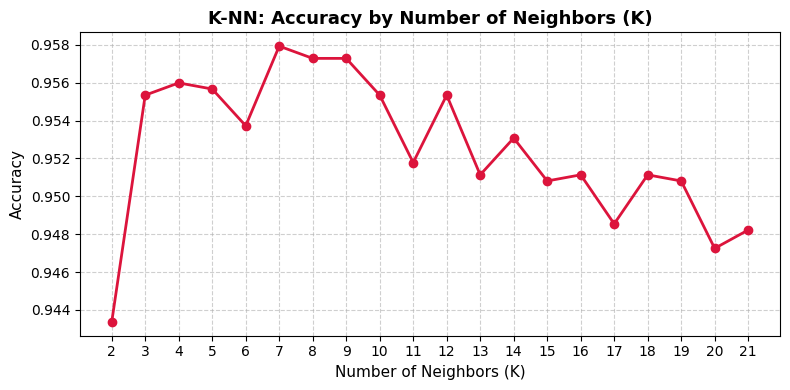

✅ 탐색 완료! 최적의 이웃 수(Best K): 7
✅ 최고 정확도: 0.9579


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\n=== 🎯 [5단계] K-NN 분류 모델 학습 및 평가 시작 ===")

# --- 1. 학습/테스트 데이터 분리 ---
# 앞선 3단계에서 만들어둔 X_scaled(표준화된 센서 데이터)와 y(활동 라벨)를 사용합니다.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("✅ 학습 데이터(Train)와 테스트 데이터(Test) 분리 완료!")
print(f"👉 학습용 데이터: {X_train.shape[0]}개, 테스트용 데이터: {X_test.shape[0]}개")


# --- 2. 최적의 K(이웃 수) 탐색 (과적합 방지를 위해 2부터 21까지 탐색) ---> 하이퍼파라미터 튜
k_range = range(2, 22)
accuracies = []

print("\n⏳ 최적의 K값을 탐색 중입니다. 잠시만 기다려주세요...")
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# 탐색 결과 시각화
plt.figure(figsize=(8, 4))
plt.plot(k_range, accuracies, marker='o', color='crimson', markersize=6, linewidth=2)
plt.xlabel('Number of Neighbors (K)', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('K-NN: Accuracy by Number of Neighbors (K)', fontsize=13, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 가장 높은 정확도를 기록한 최적의 K 도출
best_k = k_range[np.argmax(accuracies)]
print(f"✅ 탐색 완료! 최적의 이웃 수(Best K): {best_k}")
print(f"✅ 최고 정확도: {max(accuracies):.4f}")



In [5]:
# --- 3. 최적의 K값으로 최종 모델 평가 ---
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
y_pred_final = best_knn.predict(X_test)

# 성능 평가 지표 출력
print("\n=== 📊 K-NN 최종 분류 결과 (Classification Report) ===")
#activity_names 딕셔너리를 활용해 라벨명을 영문으로 매핑합니다.
target_labels = [activity_names[i] for i in sorted(activity_names.keys())]
print(classification_report(y_test, y_pred_final, target_names=target_labels))


=== 📊 K-NN 최종 분류 결과 (Classification Report) ===
                    precision    recall  f1-score   support

           Walking       0.98      1.00      0.99       539
  Walking Upstairs       0.98      0.99      0.98       424
Walking Downstairs       1.00      0.96      0.98       420
           Sitting       0.93      0.88      0.90       563
          Standing       0.89      0.93      0.91       547
            Laying       0.99      1.00      1.00       597

          accuracy                           0.96      3090
         macro avg       0.96      0.96      0.96      3090
      weighted avg       0.96      0.96      0.96      3090



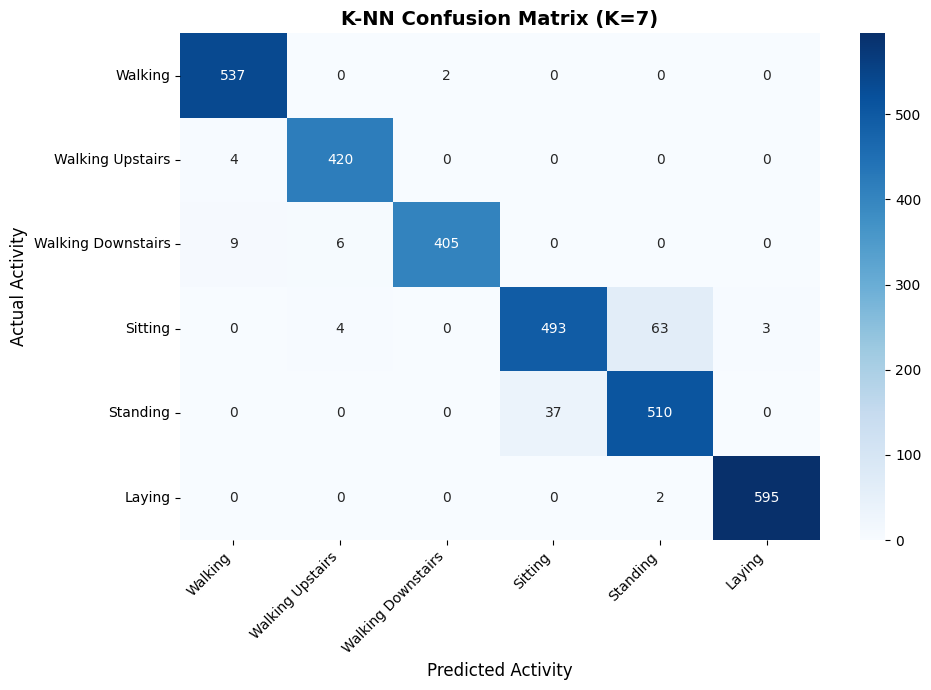

In [6]:

# --- 4. 혼동 행렬(Confusion Matrix) 시각화 ---
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_labels, yticklabels=target_labels
)
plt.title(f'K-NN Confusion Matrix (K={best_k})', fontsize=14, fontweight='bold')
plt.ylabel('Actual Activity', fontsize=12)
plt.xlabel('Predicted Activity', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

===  Random Forest 최종 분류 결과 (Classification Report) ===
                    precision    recall  f1-score   support

           Walking       0.99      0.99      0.99       539
  Walking Upstairs       0.97      0.99      0.98       424
Walking Downstairs       0.99      0.97      0.98       420
           Sitting       0.96      0.95      0.96       563
          Standing       0.95      0.96      0.96       547
            Laying       1.00      1.00      1.00       597

          accuracy                           0.98      3090
         macro avg       0.98      0.98      0.98      3090
      weighted avg       0.98      0.98      0.98      3090



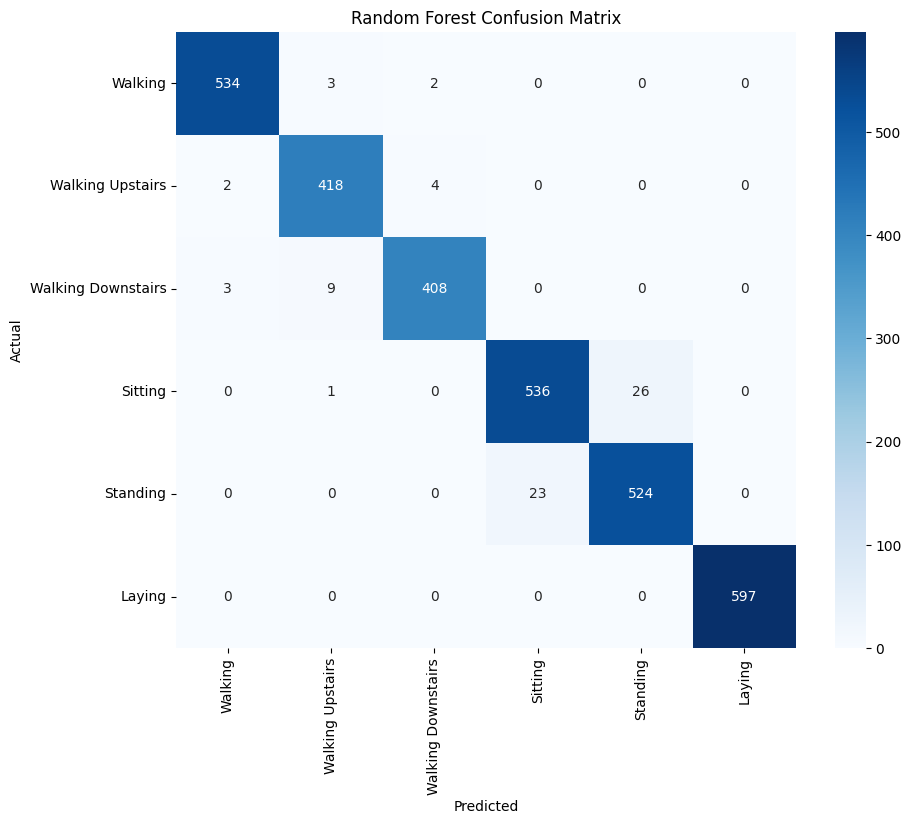

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


# 1. 랜덤 포레스트 모델 생성 및 학습
# n_estimators: 트리의 개수
# random_state: 결과 재현을 위한 고정값
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. 예측 및 최종 성능 평가
y_pred = rf_model.predict(X_test)

# 3. 분류 결과 시각화
print("===  Random Forest 최종 분류 결과 (Classification Report) ===")
target_labels = [activity_names[i] for i in sorted(activity_names.keys())]
print(classification_report(y_test, y_pred, target_names=target_labels))

# 4. 혼동 행렬 시각화
cm_rf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_labels, yticklabels=target_labels)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()